# Libraries Imported

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score



the dataset is loaded and a quick inspection is performed to understand the structure, number of rows, columns, and data types.

In [3]:
df = pd.read_csv('Fraud.csv')

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df.shape
df.info(memory_usage="deep")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 14 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   step                          int64  
 1   amount                        float64
 2   oldbalanceOrg                 float64
 3   newbalanceOrig                float64
 4   oldbalanceDest                float64
 5   newbalanceDest                float64
 6   isFraud                       int64  
 7   sender_balance_change         float64
 8   receiver_balance_change       float64
 9   transaction_to_balance_ratio  float64
 10  type_CASH_OUT                 bool   
 11  type_DEBIT                    bool   
 12  type_PAYMENT                  bool   
 13  type_TRANSFER                 bool   
dtypes: bool(4), float64(8), int64(2)
memory usage: 509.7 MB


This step checks whether the dataset contains any missing or null values. Handling missing values is a crucial part of data cleaning to ensure reliable model performance.


(There are no missing values in the dataset, so no imputation or deletion is required.)

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Outliers Using IQR Method

In [7]:
col = df['amount']
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_count = ((col < lower) | (col > upper)).sum()
outliers_count
print(f'Number of outliers in amount column: {outliers_count}')

Number of outliers in amount column: 338078


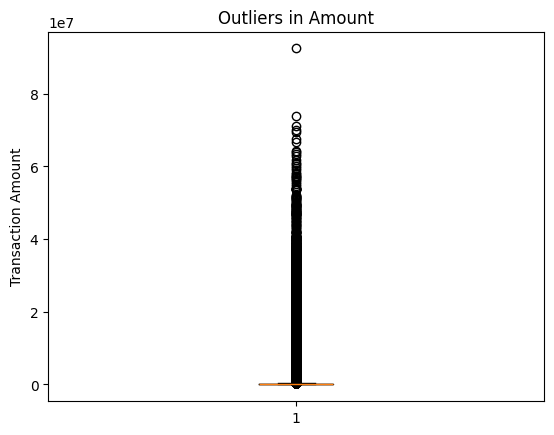

In [6]:
plt.boxplot(df['amount'])
plt.title('Outliers in Amount')
plt.ylabel('Transaction Amount')
plt.show()


In [10]:
df['amount_log'] = np.log1p(df['amount'])


The distribution of fraudulent and non-fraudulent transactions is analyzed to understand class imbalance, which is a common challenge in fraud detection problems.


In [21]:
df['isFraud'].value_counts(normalize=True) * 100


isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [25]:


df_small, _ = train_test_split(df,train_size=0.2, stratify=df['isFraud'],random_state=42)


Certain columns such as transaction IDs do not contribute to fraud prediction and may introduce noise. These columns are removed to improve model generalization.

In [23]:
df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)


**Feature Engineering**

New features are created to capture balance changes and transaction behavior that may indicate fraudulent activity.

**sender_balance_change**: Captures the actual amount deducted from the sender's account. Discrepancies between this value and the transaction amount often signal anomalies.

**receiver_balance_change**: Tracks the actual increase in the recipient's account. This is useful for spotting "ghost" transactions where money is sent but never arrives.

**transaction_to_balance_ratio**: Relativizes the transaction size against the sender's total wealth. A transfer representing 100% of an account's value is typically much higher risk than a transfer representing only 1%

In [13]:
df['sender_balance_change']= df['oldbalanceOrg'] - df['newbalanceOrig']
df['receiver_balance_change']= df['newbalanceDest'] - df['oldbalanceDest']

df['transaction_to_balance_ratio'] = df['amount_log'] / (df['oldbalanceOrg'] + 1)

In [22]:
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_log,sender_balance_change,receiver_balance_change,transaction_to_balance_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9.194276,9839.64,0.0,0.000054,False,False,True,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,7.531166,1864.28,0.0,0.000354,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,5.204007,181.00,0.0,0.028593,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,5.204007,181.00,-21182.0,0.028593,True,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,9.364703,11668.14,0.0,0.000225,False,False,True,False


'type' is a categorical feature with no natural order (PAYMENT, TRANSFER, CASH_OUT.)
 One-hot encoding converts each category into 0/1 columns, making it suitable for ML models
 Using labels like 0,1,2,3 would create a false ordinal relationship between transaction types
One-hot encoding avoids misleading the model with non-existent ordering


In [30]:
df = pd.get_dummies(df, columns=['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT'], drop_first=True)

The dataset is split into training and testing sets using stratification to preserve the original fraud distribution. This ensures unbiased model evaluation.


In [31]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [32]:
Logistic_rgssn = LogisticRegression(max_iter=1000, class_weight='balanced')
Logistic_rgssn.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,sender_balance_change,receiver_balance_change,transaction_to_balance_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0,0.057834,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0,0.087731,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0,0.994505,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0,0.994505,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0,0.280788,False,False,True,False


A Random Forest model is used due to its ability to handle non-linear patterns and imbalanced datasets while providing feature importance for interpretation.


In [33]:
Random_frst = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
Random_frst.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**The model’s performance is evaluated using precision, recall, F1-score, and ROC-AUC score, as accuracy alone is not sufficient for imbalanced datasets.**


**Model Evaluation Results:**

In [41]:
y_pred = Random_frst.predict(X_test)
y_prob = Random_frst.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("Area Under the ROC Curve (AUC):", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.98      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

Area Under the ROC Curve (AUC): 0.9994449190171073


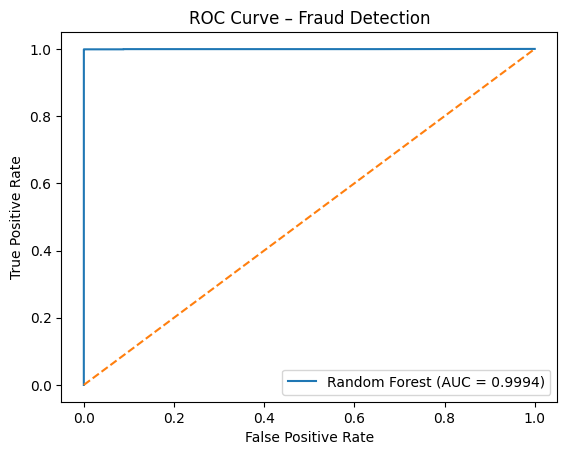

In [49]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Fraud Detection')
plt.legend()
plt.show()

Feature importance is analyzed to identify the key variables that contribute most to fraud prediction.


In [37]:
importances = pd.Series(
    Random_frst.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

importances.head(10)


sender_balance_change           0.308690
transaction_to_balance_ratio    0.274764
newbalanceOrig                  0.110883
oldbalanceOrg                   0.083848
amount                          0.054460
type_TRANSFER                   0.039927
receiver_balance_change         0.033340
type_PAYMENT                    0.032892
type_CASH_OUT                   0.021224
step                            0.017208
dtype: float64

In [ ]:


confusion_matrix(y_test, y_pred)


array([[1270854,      27],
       [      4,    1639]], dtype=int64)

I also used Stratified K-Fold Cross-Validation with a focus on the ROC-AUC score.

In [40]:


cv = StratifiedKFold(n_splits=5)
scores = cross_val_score(
    Random_frst, X, y, cv=cv, scoring='roc_auc', n_jobs=-1
)

scores.mean()


0.9990460986142636

The most influential factors such as transaction amount, balance differences, and transaction type align well with real-world fraud patterns. Fraudulent transactions typically involve sudden balance depletion or abnormal transaction behavior, validating the model’s logic.


Based on the model insights, fraud prevention strategies such as real-time transaction monitoring, OTP-based verification for high-risk transactions, and rule-based alerts for suspicious balance changes should be implemented.


The effectiveness of fraud prevention measures can be evaluated by monitoring key metrics such as reduction in fraud rate, false positives, financial loss over time, and periodic retraining of the model using updated transaction data.
